In [19]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [20]:
# Loading the data
df=pd.read_excel(r"C:\Users\USER\Documents\AI-portfolio\project 1\customer-churn-mlops\data\churn.xlsx")


In [21]:
print("Shape",df.shape)
print(df.head())


Shape (7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Mon

In [22]:
for col in df.columns:
    print(f" {col}:{df[col].dtype}")

 CustomerID:str
 Count:int64
 Country:str
 State:str
 City:str
 Zip Code:int64
 Lat Long:str
 Latitude:float64
 Longitude:float64
 Gender:str
 Senior Citizen:str
 Partner:str
 Dependents:str
 Tenure Months:int64
 Phone Service:str
 Multiple Lines:str
 Internet Service:str
 Online Security:str
 Online Backup:str
 Device Protection:str
 Tech Support:str
 Streaming TV:str
 Streaming Movies:str
 Contract:str
 Paperless Billing:str
 Payment Method:str
 Monthly Charges:float64
 Total Charges:object
 Churn Label:str
 Churn Value:int64
 Churn Score:int64
 CLTV:int64
 Churn Reason:str


In [25]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing %
Churn Reason           5174  73.463013


## Finding: Missing Values
Only one column has missing values: Churn Reason (73.5% missing).
This is expected — only churned customers have a churn reason recorded.
Churn Reason will be dropped at the preprocessing stage to prevent data leakage.
No imputation required anywhere in the dataset.

Text(0, 0.5, 'Count')

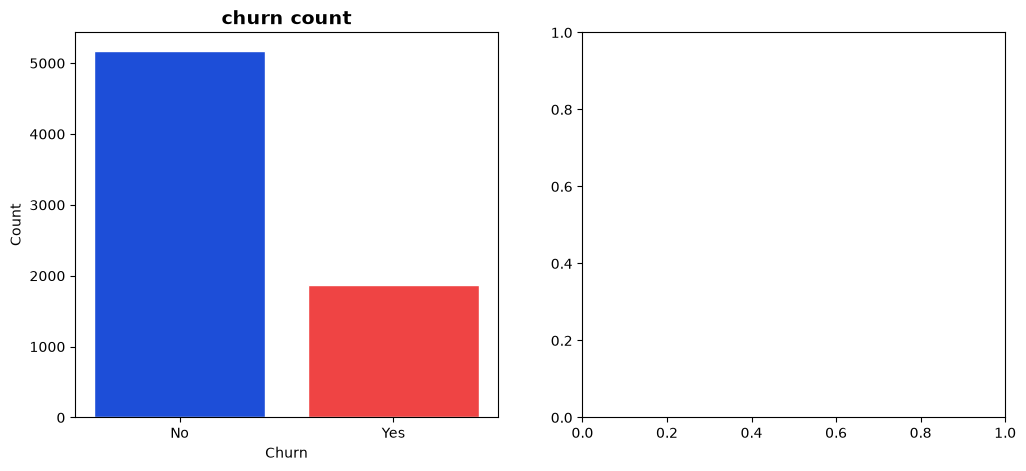

In [44]:
#Target Variable ditribution
fig, axes= plt.subplots(1,2, figsize=(12,5))
churn_count=df["Churn Label"].value_counts()
axes[0].bar(churn_count.index, churn_count.values,color=['#1D4ED8', '#EF4444'], edgecolor='white')
axes[0].set_title('churn count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

In [38]:
print(churn_count)

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
